# 02 - Mission Timeline Visualization

This notebook visualizes the Archer Midnight's mission profile as a timeline, showing how velocity and duration change across segments.

## Energy vs Power Demands

Energy is power multiplied by time. A segment with moderate power but long duration (like cruise) will consume far more energy than a high-power but short segment (like hover climb):

$$E_{segment} = P_{elec,avg} \cdot t_{segment}$$

The visualizations below reveal this trade-off: **cruise dominates the timeline**, which is why it typically dominates total energy consumption even though its instantaneous power demand is lower than hover.

In [10]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft
import matplotlib.pyplot as plt

aircraft = Aircraft('../Archer_Midnight.json')
mission = aircraft.mission

## Duration vs. Power Trade-off

The chart below plots segment duration against average electric power, with the area of each bubble proportional to energy consumed. 

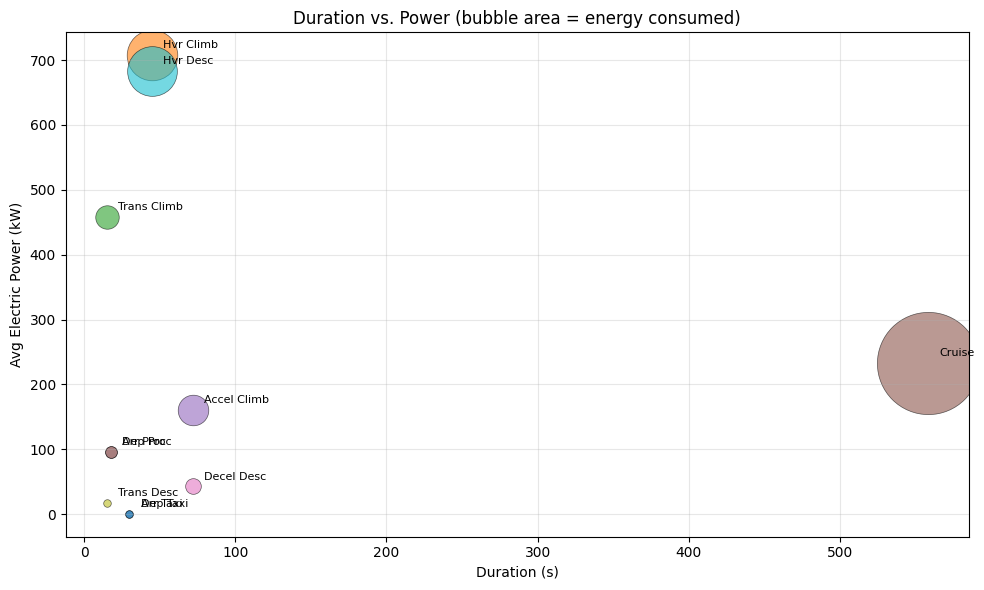

In [11]:
seg_powers = [
    ('Dep Taxi',    aircraft.depart_taxi_avg_electric_power_kw,    mission.depart_taxi_s,       aircraft.depart_taxi_energy_kw_hr),
    ('Hvr Climb',   aircraft.hover_climb_avg_electric_power_kw,    mission.hover_climb_s,       aircraft.hover_climb_energy_kw_hr),
    ('Trans Climb', aircraft.trans_climb_avg_electric_power_kw,    mission.trans_climb_s,       aircraft.trans_climb_energy_kw_hr),
    ('Dep Proc',    aircraft.depart_proc_avg_electric_power_kw,   mission.depart_proc_s,       aircraft.depart_proc_energy_kw_hr),
    ('Accel Climb', aircraft.accel_climb_avg_electric_power_kw,    mission.accel_climb_s,       aircraft.accel_climb_energy_kw_hr),
    ('Cruise',      aircraft.cruise_avg_electric_power_kw,         mission.cruise_s,            aircraft.cruise_energy_kw_hr),
    ('Decel Desc',  aircraft.decel_descend_avg_electric_power_kw,  mission.decel_descend_s,     aircraft.decel_descend_energy_kw_hr),
    ('Arr Proc',    aircraft.arrive_proc_avg_electric_power_kw,   mission.arrive_proc_s,       aircraft.arrive_proc_energy_kw_hr),
    ('Trans Desc',  aircraft.trans_descend_avg_electric_power_kw,  mission.trans_descend_s,     aircraft.trans_descend_energy_kw_hr),
    ('Hvr Desc',    aircraft.hover_descend_avg_electric_power_kw,  mission.hover_descend_s,     aircraft.hover_descend_energy_kw_hr),
    ('Arr Taxi',    aircraft.arrive_taxi_avg_electric_power_kw,    mission.arrive_taxi_s,       aircraft.arrive_taxi_energy_kw_hr),
]

fig, ax = plt.subplots(figsize=(10, 6))
for name, pwr, dur, energy in seg_powers:
    size = max(energy * 150, 30)  # scale bubble size
    ax.scatter(dur, pwr, s=size, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.annotate(name, (dur, pwr), textcoords="offset points", xytext=(8, 5), fontsize=8)

ax.set_xlabel('Duration (s)')
ax.set_ylabel('Avg Electric Power (kW)')
ax.set_title('Duration vs. Power (bubble area = energy consumed)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

Key insights from the mission timeline:

- **Cruise dominates duration**: typically 60-80% of the total mission time
- **Hover segments are short but power-intensive**: they drive peak power sizing (battery C-rate, motor, inverter ratings)
- **Energy = Power x Time**: the bubble chart reveals that cruise consumes the most energy despite lower power, because of its long duration
- The mission structure is roughly symmetric: departure phases mirror arrival phases, reflecting the climb-cruise-descend profile

**Next:** Move on to [04 - Mass and Weight Analysis] to explore MTOW iteration and mass breakdown.